In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

Data loading/Reading 

In [50]:
df=pd.read_csv(r'C:\Users\saba\Downloads\sales.csv')
df

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72
...,...,...,...,...,...,...,...,...,...,...
495,496,2024-11-20,South,Mouse,Accessories,Returning,6,314,0.23,1450.68
496,497,2024-01-04,North,Phone,Accessories,Returning,9,369,0.23,2557.17
497,498,2024-01-16,South,Keyboard,Electronics,Returning,6,722,0.14,3725.52
498,499,2024-10-06,North,Phone,Accessories,Returning,2,1449,0.12,2550.24


In [51]:
df.shape

(500, 10)

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       500 non-null    int64  
 1   date           500 non-null    str    
 2   region         500 non-null    str    
 3   product        500 non-null    str    
 4   category       500 non-null    str    
 5   customer_type  500 non-null    str    
 6   quantity       500 non-null    int64  
 7   price          500 non-null    int64  
 8   discount       500 non-null    float64
 9   sales          500 non-null    float64
dtypes: float64(2), int64(3), str(5)
memory usage: 39.2 KB


In [53]:
df.isnull().sum()

order_id         0
date             0
region           0
product          0
category         0
customer_type    0
quantity         0
price            0
discount         0
sales            0
dtype: int64

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df.columns

Index(['order_id', 'date', 'region', 'product', 'category', 'customer_type',
       'quantity', 'price', 'discount', 'sales'],
      dtype='str')

In [56]:
df['date']=pd.to_datetime(df['date'])
df

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72
...,...,...,...,...,...,...,...,...,...,...
495,496,2024-11-20,South,Mouse,Accessories,Returning,6,314,0.23,1450.68
496,497,2024-01-04,North,Phone,Accessories,Returning,9,369,0.23,2557.17
497,498,2024-01-16,South,Keyboard,Electronics,Returning,6,722,0.14,3725.52
498,499,2024-10-06,North,Phone,Accessories,Returning,2,1449,0.12,2550.24


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       500 non-null    int64         
 1   date           500 non-null    datetime64[us]
 2   region         500 non-null    str           
 3   product        500 non-null    str           
 4   category       500 non-null    str           
 5   customer_type  500 non-null    str           
 6   quantity       500 non-null    int64         
 7   price          500 non-null    int64         
 8   discount       500 non-null    float64       
 9   sales          500 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(3), str(4)
memory usage: 39.2 KB


In [58]:
df.drop(['order_id','discount'],axis=1,inplace=True) 

In [59]:
import seaborn as sns

<Axes: xlabel='sales', ylabel='Count'>

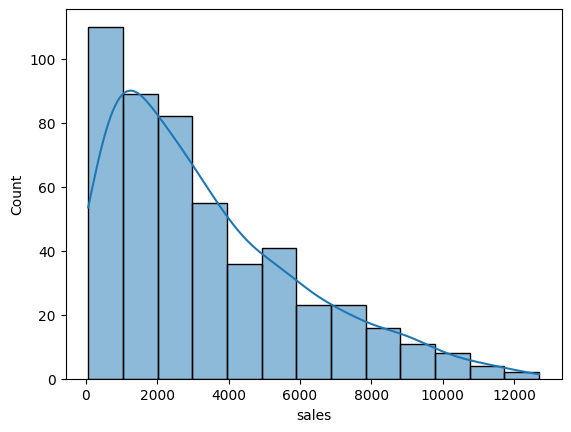

In [60]:

sns.histplot(df['sales'],kde=True)

In [61]:
df.select_dtypes(include=['float','int']).corr()

,quantity,price,sales
quantity,1.000000,0.082232,0.692406
price,0.082232,1.000000,0.668516
sales,0.692406,0.668516,1.000000


<Axes: >

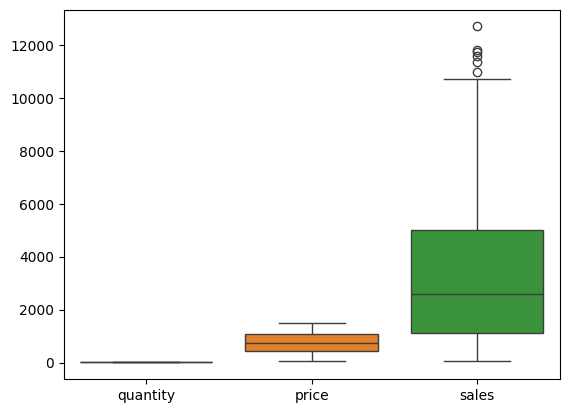

In [62]:
sns.boxplot(df)

<Axes: ylabel='sales'>

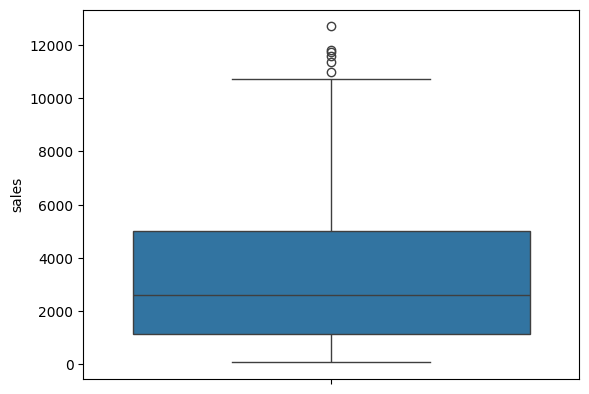

In [63]:
sns.boxplot(df['sales'])

In [64]:
Q1=df['sales'].quantile(0.25)
Q3=df['sales'].quantile(0.75)

IQR=Q3-Q1
lower_limit=Q1-1.0*IQR
upper_limit=Q3+1.0*IQR

df_clean=df[(df['sales']>=lower_limit)& (df['sales']<=upper_limit)]
df_clean.shape


(476, 8)

In [65]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_clean['customer_type']=le.fit_transform(df_clean['customer_type'])
df_clean

,date,region,product,category,customer_type,quantity,price,sales
0,2024-04-12,East,Laptop,Electronics,1,8,590,4295.20
1,2024-12-14,South,Monitor,Accessories,1,2,262,429.68
2,2024-09-27,North,Phone,Accessories,0,5,512,2329.60
3,2024-04-16,West,Mouse,Electronics,1,1,485,441.35
4,2024-03-12,West,Phone,Electronics,1,7,332,1812.72
...,...,...,...,...,...,...,...,...
495,2024-11-20,South,Mouse,Accessories,1,6,314,1450.68
496,2024-01-04,North,Phone,Accessories,1,9,369,2557.17
497,2024-01-16,South,Keyboard,Electronics,1,6,722,3725.52
498,2024-10-06,North,Phone,Accessories,1,2,1449,2550.24


In [66]:
df_clean=pd.get_dummies(df_clean,columns=['region', 'product', 'category'])
df_clean

,date,customer_type,quantity,price,sales,region_East,region_North,region_South,region_West,product_Keyboard,product_Laptop,product_Monitor,product_Mouse,product_Phone,product_Tablet,category_Accessories,category_Electronics
0,2024-04-12,1,8,590,4295.20,True,False,False,False,False,True,False,False,False,False,False,True
1,2024-12-14,1,2,262,429.68,False,False,True,False,False,False,True,False,False,False,True,False
2,2024-09-27,0,5,512,2329.60,False,True,False,False,False,False,False,False,True,False,True,False
3,2024-04-16,1,1,485,441.35,False,False,False,True,False,False,False,True,False,False,False,True
4,2024-03-12,1,7,332,1812.72,False,False,False,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2024-11-20,1,6,314,1450.68,False,False,True,False,False,False,False,True,False,False,True,False
496,2024-01-04,1,9,369,2557.17,False,True,False,False,False,False,False,False,True,False,True,False
497,2024-01-16,1,6,722,3725.52,False,False,True,False,True,False,False,False,False,False,False,True
498,2024-10-06,1,2,1449,2550.24,False,True,False,False,False,False,False,False,True,False,True,False


In [67]:
X=df_clean.drop(columns=['date', 'sales'])
y=df_clean['sales']
x_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.2)

In [68]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [69]:
y_pred

array([ -361.844121  ,  6284.21576156, -1374.96726903,  2255.23062258,
         177.83074692,  2613.90998128,  3120.38812423,  -898.54004107,
        1900.45772332,    83.0824106 ,  5232.06658506,  4209.49801571,
       -1664.25676336,  3660.46376616,  4061.91620043,  4762.2564698 ,
        1342.16846124,  3047.53021626,  3065.80949905,   902.96391094,
        2786.68760201,  4943.7584439 ,   141.89876867,  4477.17243666,
        1334.06805766,  4500.3544855 ,  3943.61795169,  6443.88067481,
        1062.66532103,  3363.57762669,   248.26583174,  2016.91243156,
        1836.14921671,  3910.72929694,  3359.39490279,  3773.40610917,
        4091.54939553,  1942.80711843,  4561.03816858,   884.23337901,
        3104.46885609,  3785.81426602,  1463.16552708,  4387.68364417,
        3511.16868684,  2130.34882487,  3569.63309534,  4105.89895812,
        3696.51227025,  -391.37968894,  1687.0696469 ,  3924.18368783,
        4240.86688237,  5542.52576025,  3503.63585241,  5579.53576061,
      

In [70]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)


0.8275596332735181

<Axes: xlabel='sales'>

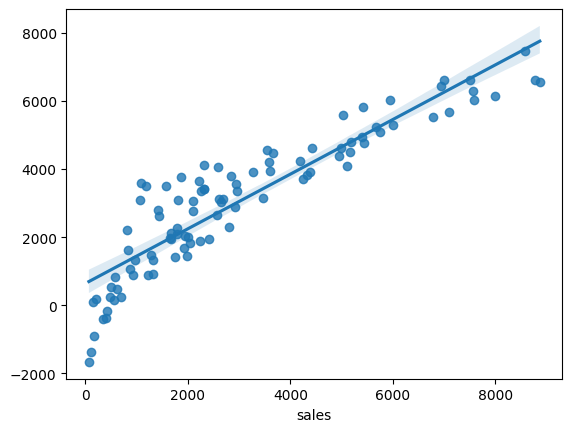

In [71]:
sns.regplot(x=y_test, y=y_pred)

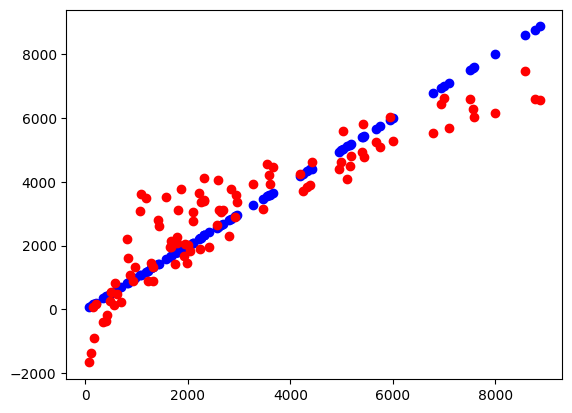

In [72]:
plt.scatter(y_test,y_test,color='blue')
plt.scatter(y_test,y_pred,color='red')